In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from scipy.integrate import solve_ivp

def retrato(A, ax, lim=3, titulo=None, autovetores=True):
    # Desenha o retrato de fase de x' = A x no quadrado [-lim, lim]^2
    A = np.array(A, dtype=float)
    s = np.linspace(-lim, lim, 40)
    X, Y = np.meshgrid(s, s)
    U = A[0, 0]*X + A[0, 1]*Y
    V = A[1, 0]*X + A[1, 1]*Y
    ax.streamplot(X, Y, U, V, color='0.55', density=1.1, linewidth=0.8, arrowsize=1)
    if autovetores:
        lam, vec = np.linalg.eig(A)
        if np.all(np.abs(lam.imag) < 1e-12):
            pares = list(zip(lam.real, vec.T.real))
            if abs(lam[0] - lam[1]) < 1e-6:
                pares = pares[:1]
            for l, v in pares:
                ax.plot([-3*lim*v[0], 3*lim*v[0]], [-3*lim*v[1], 3*lim*v[1]],
                        '--', linewidth=2, label=fr'$\lambda={l:.3g}$')
            ax.legend(loc='lower right', fontsize=8)
    ax.plot(0, 0, 'ko', markersize=5)
    ax.set_xlim(-lim, lim); ax.set_ylim(-lim, lim); ax.set_aspect('equal')
    ax.set_xlabel('$x_1$'); ax.set_ylabel('$x_2$')
    if titulo:
        ax.set_title(titulo)

def trajetoria(A, x0, T, ax, cor='b'):
    # Integra x' = A x a partir de x0 e desenha a trajetória
    A = np.array(A, dtype=float)
    sol = solve_ivp(lambda t, x: A @ x, (0, T), x0, max_step=T/500)
    ax.plot(sol.y[0], sol.y[1], color=cor, linewidth=2.5)
    ax.plot(x0[0], x0[1], 'o', color=cor, markersize=7)
    return sol

In [2]:
a, b, p, k = 0.01, 0.05, 0.1, 0.5
M = np.array([[-a, b], [a, p - k - b]])
print("tr M =", np.trace(M), "  det M =", np.linalg.det(M))

lam, V = np.linalg.eig(M)
V = V / V[0]                     # normaliza: primeira componente igual a 1
for l, v in zip(lam, V.T):
    print(f"autovalor {l:.4f}   autovetor {np.round(v, 4)}")

tr M = -0.46   det M = 0.004000000000000002
autovalor -0.0089   autovetor [1.     0.0227]
autovalor -0.4511   autovetor [ 1.     -8.8227]


c1, c2 = [ 2127.97627393 -1127.97627393]


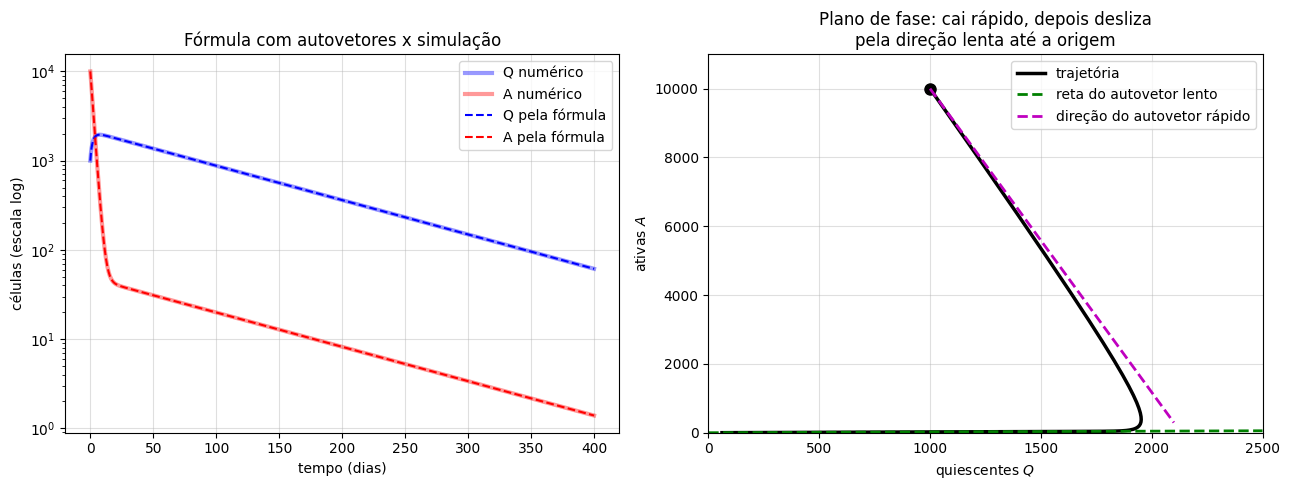

In [3]:
x0 = np.array([1000, 10000])
coef = np.linalg.solve(V, x0)              # c1 v1 + c2 v2 = x0
print("c1, c2 =", coef)

t = np.linspace(0, 400, 800)
x_exata = (V * coef) @ np.exp(np.outer(lam, t))
sol = solve_ivp(lambda t, x: M @ x, (0, 400), x0, t_eval=t, rtol=1e-9, atol=1e-12)

fig, axs = plt.subplots(1, 2, figsize=(13, 5))
axs[0].semilogy(t, sol.y[0], 'b', linewidth=3, alpha=0.4, label='Q numérico')
axs[0].semilogy(t, sol.y[1], 'r', linewidth=3, alpha=0.4, label='A numérico')
axs[0].semilogy(t, x_exata[0], 'b--', label='Q pela fórmula')
axs[0].semilogy(t, x_exata[1], 'r--', label='A pela fórmula')
axs[0].set_xlabel("tempo (dias)"); axs[0].set_ylabel("células (escala log)")
axs[0].set_title("Fórmula com autovetores x simulação"); axs[0].legend(); axs[0].grid(True, alpha=0.4)

ax = axs[1]
ax.plot(sol.y[0], sol.y[1], 'k', linewidth=2.5, label='trajetória')
ax.plot(*x0, 'ko', markersize=8)
i_lento, i_rapido = np.argmax(lam), np.argmin(lam)
v_l, v_r = V[:, i_lento], V[:, i_rapido]
ax.plot([0, 2500*v_l[0]], [0, 2500*v_l[1]], 'g--', linewidth=2, label='reta do autovetor lento')
ax.plot([x0[0], x0[0] + 1100*v_r[0]], [x0[1], x0[1] + 1100*v_r[1]], 'm--', linewidth=2,
        label='direção do autovetor rápido')
ax.set_xlim(0, 2500); ax.set_ylim(0, 11000)
ax.set_xlabel("quiescentes $Q$"); ax.set_ylabel("ativas $A$")
ax.set_title("Plano de fase: cai rápido, depois desliza\npela direção lenta até a origem")
ax.legend(); ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

In [4]:
for k_ in [0.2, 0.5, 1, 2, 5]:
    Mk = np.array([[-a, b], [a, p - k_ - b]])
    l = np.sort(np.linalg.eigvals(Mk))
    print(f"k = {k_:4}:   autovalor rápido = {l[0]:8.4f}   autovalor lento = {l[1]:8.5f}")

k =  0.2:   autovalor rápido =  -0.1535   autovalor lento = -0.00652
k =  0.5:   autovalor rápido =  -0.4511   autovalor lento = -0.00887
k =    1:   autovalor rápido =  -0.9505   autovalor lento = -0.00947
k =    2:   autovalor rápido =  -1.9503   autovalor lento = -0.00974
k =    5:   autovalor rápido =  -4.9501   autovalor lento = -0.00990


tr = -1.5   det = 3.5   Delta = -11.75
autovalores: [-0.75+1.71391365j -0.75-1.71391365j]


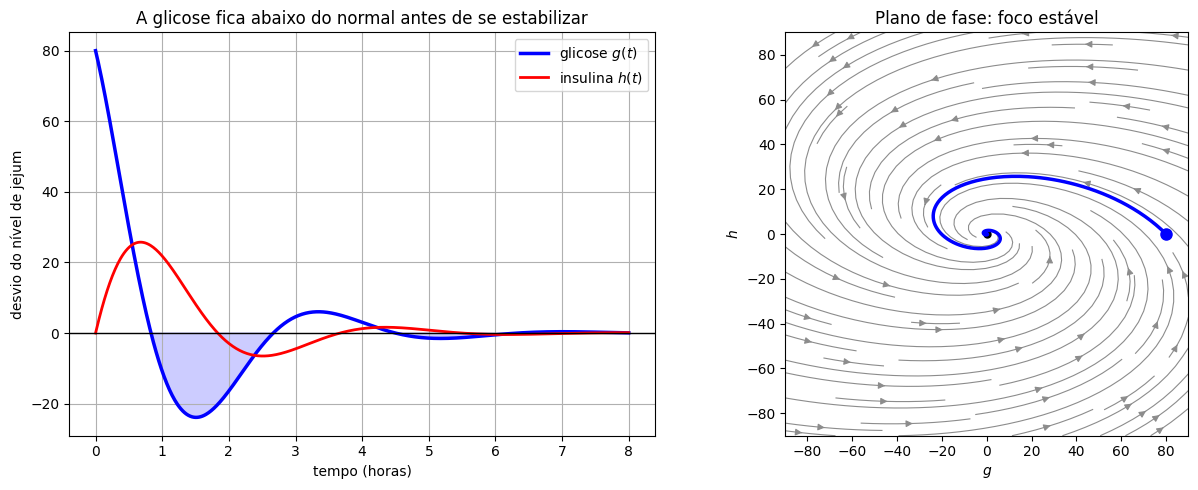

In [5]:
m1, m2, m3, m4 = 1.0, 3.0, 0.5, 1.0
G = np.array([[-m1, -m2], [m4, -m3]])
print("tr =", np.trace(G), "  det =", np.linalg.det(G), "  Delta =", np.trace(G)**2 - 4*np.linalg.det(G))
print("autovalores:", np.linalg.eigvals(G))

t = np.linspace(0, 8, 600)
sol = solve_ivp(lambda t, x: G @ x, (0, 8), [80, 0], t_eval=t)

fig, axs = plt.subplots(1, 2, figsize=(13, 5))
axs[0].plot(t, sol.y[0], 'b', linewidth=2.5, label='glicose $g(t)$')
axs[0].plot(t, sol.y[1], 'r', linewidth=2, label='insulina $h(t)$')
axs[0].axhline(0, color='k', linewidth=1)
axs[0].fill_between(t, sol.y[0], 0, where=sol.y[0] < 0, color='b', alpha=0.2)
axs[0].set_xlabel("tempo (horas)"); axs[0].set_ylabel("desvio do nível de jejum")
axs[0].set_title("A glicose fica abaixo do normal antes de se estabilizar")
axs[0].legend(); axs[0].grid(True)

retrato(G, axs[1], lim=90, autovetores=False, titulo="Plano de fase: foco estável")
axs[1].plot(sol.y[0], sol.y[1], 'b', linewidth=2.5)
axs[1].plot(80, 0, 'bo', markersize=8)
axs[1].set_xlabel("$g$"); axs[1].set_ylabel("$h$")
plt.tight_layout()
plt.show()

In [6]:
w0 = np.sqrt(np.linalg.det(G))
print(f"omega_0 = {w0:.3f} rad/h   ->   período natural T0 = 2*pi/omega_0 = {2*np.pi/w0:.2f} horas")

omega_0 = 1.871 rad/h   ->   período natural T0 = 2*pi/omega_0 = 3.36 horas
